# EDA — Nettoyage complet (doublons, nulls, outliers)

Version consolidée, cohérente avec les correctifs de `build_dataset_final.py` (dédoublonnage
`RADICAL`/`produit_digitaux`, `assert n_final == n_perimetre`).

**Ce qui a changé par rapport à la version précédente de ce notebook :**
- Bascule **local ↔ MinIO** via un seul flag (`LOCAL_MODE`), au lieu de chemins codés en dur
  incohérents entre cellules.
- Bug `GENDER` corrigé : les valeurs déjà bien encodées (`"Féminin"`) n'étaient pas préservées
  et se faisaient effacer silencieusement par l'ancien `.otherwise(None)`.
- `dataset_a_scorer` n'est plus oublié : une seule fonction `traiter_dataset(..., is_train=...)`
  gère les deux jeux au lieu d'un bloc `__main__` qui ne traitait que le train.
- Plus de cellules dupliquées qui s'écrasent (l'ancien notebook redéfinissait deux fois
  `corriger_valeurs_impossibles` et `apprendre_bornes_plafonnement` dans des cellules différentes).
- Sauvegarde des bornes IQR corrigée : `open()`/`json.dump()` ne marchent que sur des chemins
  locaux, jamais sur `s3a://` — bascule automatique vers un DataFrame Spark en mode cluster.
- Réduction de dimensions transformée en fonction réutilisable, appelée identiquement sur les
  deux jeux (avant : appliquée une fois à la main, schémas train/scoring non garantis identiques).
- Encodage catégoriel préparé (`stages_encodage_categoriel`) mais volontairement **pas appliqué**
  ici — il doit être *fit* dans le `Pipeline` d'entraînement, sur le vrai train complet, pas sur
  ce fichier de test local.

## 0. Imports et configuration

In [2]:
import os
import json

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer, ImputerModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [4]:
# ═══ Bascule LOCAL / MinIO ═══
LOCAL_MODE = False  # <-- bucket MinIO complet (33 parquet)

if LOCAL_MODE:
    # Test sur un seul fichier téléchargé localement
    PATH_TRAIN_IN = "part-00000.parquet"
    PATH_TRAIN_OUT = "new_test/part-00000_final.parquet"
    PATH_SCORER_IN = None   # pas encore testé en local
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "./models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "./models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "./models/outlier_bounds.json"
    FLAGS_A_DROPPER_PATH = "./models/flags_extreme_a_dropper.json"
else:
    # Cluster / MinIO (bucket complet)
    # CORRECTIF : bucket "processed-data" ne contient que deux dossiers reels --
    # dataset_eligibilite/ (ce qu'on traite ici) et dataset_produits/ (hors perimetre
    # pour l'instant, prediction d'eligibilite uniquement). Les anciens chemins
    # dataset_train_produits/ et dataset_a_scorer/ n'existent pas dans ce bucket.
    PATH_TRAIN_IN = "s3a://processed-data/dataset_eligibilite/"
    PATH_TRAIN_OUT = "s3a://processed-data/dataset_eligibilite_final/"
    # Pas encore de dataset a scorer separe pour l'eligibilite -- laisse a None
    # (meme convention que la branche LOCAL_MODE=True) jusqu'a ce qu'il existe sur MinIO.
    PATH_SCORER_IN = None
    PATH_SCORER_OUT = None
    IMPUTER_MODEL_PATH = "s3a://ml-scoring/models/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = "s3a://ml-scoring/models/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = "s3a://ml-scoring/models/outlier_bounds/"
    FLAGS_A_DROPPER_PATH = "s3a://ml-scoring/models/flags_extreme_a_dropper/"


In [5]:
IQR_K = 1.5
SEUIL_TAUX_ACTIVATION_FLAG = 0.03  # 3% -- flags _etait_extreme actives sur moins
                                    # de ce seuil sont droppes (quasi aucun pouvoir
                                    # de separation, juste du bruit/dimensionnalite)
SEUIL_MAX_MOIS_OBSERVES = 36
SEUIL_MAX_ENFANTS = 12
SEUIL_ZERO_INFLATED = 0.5  # part de zéros au-delà de laquelle une colonne est
                            # traitée en zero-inflated (quantiles sur valeurs > 0)

COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde", "nb_mois_avec_flux", "nb_operations_gab",
    "nb_retraits", "nb_paiements_digitaux", "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]

# Volontairement SANS solde_moyen/solde_min/solde_max : un découvert
# (solde négatif) est un état de compte légitime, pas une erreur.
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen", "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]

COLS_A_PLAFONNER = [
    "solde_moyen", "solde_min", "solde_max", "depot_moyen",
    "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]

IMPUTER_INPUT_COLS = ["anciennete_digitale_jours", "recence_gab_jours"]
IMPUTER_OUTPUT_COLS = ["anciennete_digitale_jours_imp", "recence_gab_jours_imp"]

# Colonnes catégorielles à faible cardinalité -- PAS encodées dans ce notebook
# (voir section 7 : encodage préparé pour le Pipeline d'entraînement).
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS",
]


In [6]:
def get_spark() -> SparkSession:
    # CORRECTIF (executors exit 1, driver-url = 10.255.255.254 injoignable depuis Docker) :
    # Spark auto-detecte sinon l'IP NAT interne de WSL comme adresse du driver -- les
    # executors (dans le reseau Docker) ne peuvent pas la joindre. On force ici l'IP reelle
    # de l'interface reseau de la machine (celle utilisee pour sortir vers le reseau, donc
    # aussi celle joignable par le pont Docker), via un socket UDP factice (aucun paquet
    # n'est reellement envoye a 8.8.8.8, juste utilise pour resoudre l'IP source locale).
    import socket
    _s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    try:
        _s.connect(("8.8.8.8", 80))
        DRIVER_HOST_IP = _s.getsockname()[0]
    finally:
        _s.close()
    print(f"DRIVER_HOST_IP detecte : {DRIVER_HOST_IP}")

    builder = SparkSession.builder.appName("eda_clean_outliers")
    if LOCAL_MODE:
        builder = builder.master("local[*]")
    else:
        builder = (
            builder.master("spark://spark-master:7077")
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
            # CORRECTIF (ClassNotFoundException: S3AFileSystem) : pip install pyspark
            # ne fournit PAS hadoop-aws / aws-java-sdk-bundle -- fs.s3a.impl pointe vers une
            # classe absente du classpath du driver sans ca. Versions alignees sur le
            # Hadoop 3.3.4 embarque par Spark 3.5.1 (build hadoop3).
            .config("spark.jars.packages",
                    "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
            # CORRECTIF (executors exit 1, driver-url = 10.255.255.254) : sans ca, Spark
            # auto-detecte l'IP WSL-NAT du driver, injoignable depuis le worker Docker.
            # DRIVER_HOST_IP est calcule plus haut (cellule get_spark, avant le builder).
            .config("spark.driver.host", DRIVER_HOST_IP)
            .config("spark.driver.bindAddress", "0.0.0.0")
        )
    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    spark.conf.set("spark.sql.shuffle.partitions", 8)
    return spark


spark = get_spark()


DRIVER_HOST_IP detecte : 172.21.106.179


26/07/18 16:07:04 WARN Utils: Your hostname, Speranz resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/18 16:07:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/mr_tarouzi/bigdata-cluster/.venv/lib/python3.8/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/mr_tarouzi/.ivy2/cache
The jars for the packages stored in: /home/mr_tarouzi/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-508626cd-af87-4f93-9827-6ad4da48df17;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 1694ms :: artifacts dl 74ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dw

## 1. Doublons

Vérifié **avant** tout calcul de médiane/quantile (nulls, imputer, bornes IQR) — des doublons
fausseraient ces statistiques.

In [7]:
def verifier_et_dedupliquer(df: DataFrame, label: str) -> DataFrame:
    """Unicité de RADICAL (normalement déjà garantie par build_dataset_final.py
    -- ce check confirme juste l'absence de régression) + suppression des
    doublons stricts (lignes entièrement identiques)."""
    print(f"\n{'=' * 20} DOUBLONS : {label} {'=' * 20}")

    total = df.count()
    radical_distincts = df.select("RADICAL").distinct().count()
    print(f"Lignes : {total} | RADICAL distincts : {radical_distincts}")
    if total != radical_distincts:
        print(f"ATTENTION : {total - radical_distincts} RADICAL en double -- "
              f"ne devrait pas arriver ici, vérifier build_dataset_final.py")
    else:
        print("OK : RADICAL unique.")

    sans_doublons = df.dropDuplicates().count()
    if total != sans_doublons:
        print(f"ATTENTION : {total - sans_doublons} doublon(s) strict(s) -> suppression")
        df = df.dropDuplicates()
    else:
        print("OK : aucun doublon strict.")

    return df


## 2. Nulls

Chaque règle correspond à une décision métier documentée (section 6.5/6.5bis du guide), pas une
imputation générique.

In [8]:
def clean_dataset(df: DataFrame, label: str) -> DataFrame:
    n_avant = df.count()

    # --- GENDER : encodage cassé ("FÃ©minin") normalisé -- CORRECTIF : les valeurs
    #     déjà bien encodées ("Féminin") sont explicitement préservées, sinon elles
    #     tombent dans .otherwise(None) et se font effacer silencieusement. ---
    if "GENDER" in df.columns:
        df = df.withColumn(
            "GENDER",
            F.when(F.col("GENDER").isin("FÃ©minin", "Féminin"), "F")
             .when(F.col("GENDER") == "Masculin", "M")
             .otherwise(None),
        )

    if "LIBELLE_VILLE" in df.columns:
        df = df.drop("LIBELLE_VILLE")

    subset_dropna = [c for c in ["BPR", "GENDER"] if c in df.columns]
    if subset_dropna:
        df = df.dropna(subset=subset_dropna)

    if "NOMBRE_ENFANT" in df.columns:
        df = df.fillna({"NOMBRE_ENFANT": 0})

    if "TAILLE_ENTREPRI" in df.columns:
        df = df.fillna({"TAILLE_ENTREPRI": "PARTICULIER"})

    pack_cols = {}
    if "pack_actuel" in df.columns:
        pack_cols["pack_actuel"] = "SANS_PACK"
    if "pack_etat" in df.columns:
        pack_cols["pack_etat"] = "SANS_ETAT"
    if pack_cols:
        df = df.fillna(pack_cols)

    montants_zero = [c for c in ["depot_moyen", "montant_moyen_gab"] if c in df.columns]
    if montants_zero:
        df = df.fillna({c: 0.0 for c in montants_zero})

    if "digital_date_activation" in df.columns:
        df = (
            df.withColumn(
                "jamais_active_digital",
                F.when(F.col("digital_date_activation").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "anciennete_digitale_jours",
                F.when(F.col("digital_date_activation").isNull(), F.lit(None))
                .otherwise(F.datediff(F.current_date(), F.to_date("digital_date_activation", "dd/MM/yyyy"))),
            )
            .drop("digital_date_activation")
        )

    if "derniere_operation_gab" in df.columns:
        df = (
            df.withColumn(
                "jamais_utilise_gab",
                F.when(F.col("derniere_operation_gab").isNull(), 1).otherwise(0),
            )
            .withColumn(
                "recence_gab_jours",
                F.when(F.col("derniere_operation_gab").isNull(), F.lit(None))
                .otherwise(F.datediff(F.current_date(), F.to_date(F.col("derniere_operation_gab"), "dd/MM/yyyy HH:mm:ss"))),
            )
            .drop("derniere_operation_gab")
        )

    n_apres = df.count()
    print(f"    [{label}] Lignes avant : {n_avant} | après nettoyage nulls : {n_apres}")
    return df


In [9]:
def fit_and_apply_imputer_on_train(df_train: DataFrame) -> DataFrame:
    """Fit UNIQUEMENT sur le train. ImputerModel.write()/.load() fonctionnent
    nativement en local ET en s3a:// (API de persistance Spark ML) -- pas de
    bascule LOCAL_MODE nécessaire ici, contrairement aux bornes IQR plus bas."""
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_train.columns]
    if not cols_present:
        return df_train
    out_cols = [IMPUTER_OUTPUT_COLS[IMPUTER_INPUT_COLS.index(c)] for c in cols_present]

    imputer = Imputer(inputCols=cols_present, outputCols=out_cols, strategy="median")
    imputer_model = imputer.fit(df_train)

    medianes = {c: df_train.approxQuantile(c, [0.5], 0.01)[0] for c in cols_present}
    print(f"Médianes apprises sur le train : {medianes}")

    df_train_imp = imputer_model.transform(df_train).drop(*cols_present)
    imputer_model.write().overwrite().save(IMPUTER_MODEL_PATH)
    print(f"Modèle d\'imputation sauvegardé : {IMPUTER_MODEL_PATH}")
    return df_train_imp


def apply_saved_imputer(df_scorer: DataFrame) -> DataFrame:
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_scorer.columns]
    if not cols_present:
        return df_scorer
    imputer_model = ImputerModel.load(IMPUTER_MODEL_PATH)
    return imputer_model.transform(df_scorer).drop(*cols_present)


## 3. Outliers — diagnostic

À lire avant de fixer `IQR_K` ou toute règle de correction.

In [10]:
def rapport_diagnostic(df: DataFrame, cols: list = None) -> None:
    if cols is None:
        cols = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float")]
    print(f"\n{'=' * 20} DIAGNOSTIC VALEURS ABERRANTES {'=' * 20}")
    for c in cols:
        if c not in df.columns:
            continue
        stats = df.select(F.min(c).alias("min"), F.max(c).alias("max"), F.mean(c).alias("mean")).collect()[0]
        q1, med, q3, p01, p99 = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.01, 0.99], 0.01)
        iqr = q3 - q1
        borne_basse, borne_haute = q1 - IQR_K * iqr, q3 + IQR_K * iqr
        n_negatifs = df.filter(F.col(c) < 0).count()
        n_hors_bornes = df.filter((F.col(c) < borne_basse) | (F.col(c) > borne_haute)).count()
        print(f"{c:28s} min={stats['min']!s:>12} max={stats['max']!s:>14} mean={stats['mean']:.1f} "
              f"médiane={med:.1f} p1={p01:.1f} p99={p99:.1f} "
              f"bornes_IQR=[{borne_basse:.1f},{borne_haute:.1f}] négatifs={n_negatifs} hors_bornes={n_hors_bornes}")


def rapport_dates_naissance(df: DataFrame, col: str = "DATE_OF_BIRTH") -> None:
    if col not in df.columns:
        return
    df_age = df.withColumn("_age_tmp", F.floor(F.datediff(F.current_date(), F.to_date(F.col(col), "dd/MM/yyyy")) / 365.25))
    print(f"\n{'=' * 20} DIAGNOSTIC {col} {'=' * 20}")
    df_age.select(F.min("_age_tmp").alias("age_min"), F.max("_age_tmp").alias("age_max")).show()
    print(f"Dates dans le futur : {df_age.filter(F.col('_age_tmp') < 0).count()}")
    print(f"Âge < 16 ans : {df_age.filter((F.col('_age_tmp') >= 0) & (F.col('_age_tmp') < 16)).count()}")
    print(f"Âge > 100 ans : {df_age.filter(F.col('_age_tmp') > 100).count()}")


## 4. Valeurs impossibles (catégorie 1)

Compteurs/montants négatifs, âges absurdes : des erreurs de données, pas des outliers
statistiques. **Le train peut perdre des lignes ; le scoring ne perd jamais de client**, seulement
plafonné.

In [11]:
def corriger_valeurs_impossibles(df: DataFrame, is_train: bool) -> DataFrame:
    n_avant = df.count()

    for c in COLS_COMPTAGE_NON_NEGATIVES:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0).otherwise(F.col(c)))

    c_mois = "nb_mois_observes_solde"
    if c_mois in df.columns:
        df = df.withColumn(f"{c_mois}_etait_extreme", F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, 1).otherwise(0))
        df = df.withColumn(c_mois, F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, F.lit(SEUIL_MAX_MOIS_OBSERVES)).otherwise(F.col(c_mois)))

    c_enfants = "NOMBRE_ENFANT"
    if c_enfants in df.columns:
        df = df.withColumn(f"{c_enfants}_etait_extreme", F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, 1).otherwise(0))
        df = df.withColumn(c_enfants, F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, F.lit(SEUIL_MAX_ENFANTS)).otherwise(F.col(c_enfants)))

    for c in COLS_MONTANT_NON_NEGATIFS:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0.0).otherwise(F.col(c)))

    if "DATE_OF_BIRTH" in df.columns:
        df = df.withColumn("_age_tmp", F.floor(F.datediff(F.current_date(), F.to_date(F.col("DATE_OF_BIRTH"), "dd/MM/yyyy")) / 365.25))
        n_suspect = df.filter((F.col("_age_tmp") < 16) | (F.col("_age_tmp") > 100)).count()
        if is_train:
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) -> lignes supprimées (train)")
            df = df.filter((F.col("_age_tmp") >= 16) & (F.col("_age_tmp") <= 100))
        elif n_suspect > 0:
            print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (scoring, non supprimés, plafonnés plus loin)")
        df = df.drop("_age_tmp")

    n_apres = df.count()
    if is_train:
        print(f"  Lignes avant/après (valeurs impossibles, train) : {n_avant} -> {n_apres}")
    return df


## 5. Plafonnement statistique — winsorisation IQR (catégorie 3)

Détection **zero-inflated** avant de calculer l'IQR : sur une colonne où 50%+ des valeurs valent 0
(pas d'opération GAB, pas de vignette), l'IQR brut s'effondre à `[0, 0]` et écraserait toute valeur
réelle — on calcule alors les quantiles sur les valeurs strictement positives uniquement.

Bornes **apprises sur le train**, sauvegardées, puis **rechargées telles quelles** pour le scoring
(même principe de non-fuite que l'`Imputer`).

In [12]:
def detecter_colonnes_zero_inflated(df_train: DataFrame, cols: list) -> set:
    n_total = df_train.count()
    zero_inflated = set()
    for c in cols:
        if c not in df_train.columns:
            continue
        part_zero = (df_train.filter(F.col(c) == 0).count() / n_total) if n_total else 0
        if part_zero >= SEUIL_ZERO_INFLATED:
            zero_inflated.add(c)
            print(f"  {c:28s} -> zero-inflated ({part_zero:.0%} de zéros)")
    return zero_inflated


def apprendre_bornes_plafonnement(df_train: DataFrame, cols: list = None) -> dict:
    if cols is None:
        cols = COLS_A_PLAFONNER
    print("\nDétection des colonnes zero-inflated (train) :")
    cols_zero_inflated = detecter_colonnes_zero_inflated(df_train, cols)

    bornes = {}
    for c in cols:
        if c not in df_train.columns:
            continue
        est_zi = c in cols_zero_inflated
        base_df = df_train.filter(F.col(c) > 0) if est_zi else df_train
        if base_df.count() < 10:
            continue
        q1, q3 = base_df.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lo, hi = q1 - IQR_K * iqr, q3 + IQR_K * iqr
        if est_zi:
            lo = min(lo, 0.0)
        bornes[c] = {"min": lo, "max": hi}

    print(f"\nBornes apprises sur le train ({len(bornes)} colonnes) :")
    for c, b in bornes.items():
        tag = " [zero-inflated]" if c in cols_zero_inflated else ""
        print(f"  {c:28s} -> [{b['min']:.1f}, {b['max']:.1f}]{tag}")

    sauvegarder_bornes(bornes)
    return bornes


def sauvegarder_bornes(bornes: dict) -> None:
    """CORRECTIF vs la version précédente : open()/json.dump ne fonctionnent QUE
    sur des chemins locaux, jamais sur s3a://. En mode cluster, on passe par un
    DataFrame Spark (déjà connecté à S3A) plutôt que par un fichier Python classique."""
    if LOCAL_MODE:
        os.makedirs(os.path.dirname(OUTLIER_BOUNDS_PATH) or ".", exist_ok=True)
        with open(OUTLIER_BOUNDS_PATH, "w") as f:
            json.dump(bornes, f, indent=2)
    else:
        rows = [(c, float(b["min"]), float(b["max"])) for c, b in bornes.items()]
        spark.createDataFrame(rows, ["colonne", "borne_min", "borne_max"]) \
            .write.mode("overwrite").json(OUTLIER_BOUNDS_PATH)
    print(f"Bornes sauvegardées : {OUTLIER_BOUNDS_PATH}")


def charger_bornes_plafonnement() -> dict:
    if LOCAL_MODE:
        with open(OUTLIER_BOUNDS_PATH) as f:
            return json.load(f)
    df_bornes = spark.read.json(OUTLIER_BOUNDS_PATH)
    return {r["colonne"]: {"min": r["borne_min"], "max": r["borne_max"]} for r in df_bornes.collect()}


def appliquer_plafonnement(df: DataFrame, bornes: dict) -> DataFrame:
    n_plafonnes_total = 0
    for c, b in bornes.items():
        if c not in df.columns:
            continue
        lo, hi = b["min"], b["max"]
        df = df.withColumn(f"{c}_etait_extreme", F.when((F.col(c) < lo) | (F.col(c) > hi), 1).otherwise(0))
        n_hors = df.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
        n_plafonnes_total += n_hors
        if n_hors > 0:
            print(f"  {c} : {n_hors} valeur(s) plafonnée(s) vers [{lo:.1f}, {hi:.1f}]")
        df = df.withColumn(c, F.when(F.col(c) < lo, F.lit(lo)).when(F.col(c) > hi, F.lit(hi)).otherwise(F.col(c)))
    print(f"  Total plafonné (toutes colonnes) : {n_plafonnes_total}")
    return df


## 5bis. Suppression des flags `_etait_extreme` à faible variance

Un flag activé sur moins de `SEUIL_TAUX_ACTIVATION_FLAG` (3%) des clients n'apporte
quasiment aucun pouvoir de séparation pour le modèle et ajoute juste de la dimensionnalité
inutile. Liste apprise **sur le train uniquement**, sauvegardée, puis **rechargée telle
quelle** pour le scoring -- même principe de non-fuite que l'Imputer et les bornes IQR.

In [13]:
def identifier_flags_a_dropper(df_train: DataFrame, seuil: float = SEUIL_TAUX_ACTIVATION_FLAG) -> list:
    """Calcule le taux d'activation de chaque flag _etait_extreme sur le train
    et retourne la liste de ceux a dropper (taux < seuil)."""
    flags = [c for c in df_train.columns if c.endswith("_etait_extreme")]
    if not flags:
        return []

    n_total = df_train.count()
    taux = {
        c: (df_train.filter(F.col(c) == 1).count() / n_total if n_total else 0.0)
        for c in flags
    }

    print(f"\nTaux d'activation des flags _etait_extreme (seuil = {seuil:.0%}) :")
    for c, t in sorted(taux.items(), key=lambda x: x[1]):
        print(f"  {c:45s} {t:6.2%}  [{'DROP' if t < seuil else 'garde'}]")

    flags_a_dropper = [c for c, t in taux.items() if t < seuil]
    print(f"\n{len(flags_a_dropper)}/{len(flags)} flag(s) a dropper : {flags_a_dropper}")
    return flags_a_dropper


def sauvegarder_flags_a_dropper(flags_a_dropper: list) -> None:
    """Meme logique que sauvegarder_bornes : open()/json.dump ne marchent
    que sur des chemins locaux, jamais sur s3a://."""
    if LOCAL_MODE:
        os.makedirs(os.path.dirname(FLAGS_A_DROPPER_PATH) or ".", exist_ok=True)
        with open(FLAGS_A_DROPPER_PATH, "w") as f:
            json.dump(flags_a_dropper, f, indent=2)
    else:
        spark.createDataFrame([(c,) for c in flags_a_dropper], ["colonne"]) \
            .write.mode("overwrite").json(FLAGS_A_DROPPER_PATH)
    print(f"Liste des flags a dropper sauvegardee : {FLAGS_A_DROPPER_PATH}")


def charger_flags_a_dropper() -> list:
    if LOCAL_MODE:
        with open(FLAGS_A_DROPPER_PATH) as f:
            return json.load(f)
    df_flags = spark.read.json(FLAGS_A_DROPPER_PATH)
    return [r["colonne"] for r in df_flags.collect()]


def dropper_flags_extreme(df: DataFrame, flags_a_dropper: list) -> DataFrame:
    flags_presents = [c for c in flags_a_dropper if c in df.columns]
    if flags_presents:
        df = df.drop(*flags_presents)
        print(f"Flags _etait_extreme supprimes ({len(flags_presents)}) : {flags_presents}")
    return df


## 6. Réduction de dimensions

Transformée en **fonction unique**, appelée identiquement sur train et scoring — avant, ces
transformations (corrélation, `age_client`, `solde_volatilite_relative`) n'étaient faites qu'une
fois à la main, avec le risque que train et scoring finissent avec des colonnes différentes et
fassent planter le `VectorAssembler` au moment du scoring.

In [14]:
DATE_REFERENCE_STR = "31/12/2025"  # année du fichier le plus récent (OPK2025/SOLDE_2025)


def reduire_dimensions_et_deriver_features(df: DataFrame) -> DataFrame:
    cols_techniques = ["RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "CCLE"]
    df = df.drop(*[c for c in cols_techniques if c in df.columns])

    if "digital_toujours_abonne" in df.columns:
        df = df.drop("digital_toujours_abonne")  # r=-0.999 avec jamais_active_digital

    if all(c in df.columns for c in ["solde_max", "solde_min", "solde_moyen"]):
        df = (
            df.withColumn(
                # solde_moyen <= 0 (decouvert moyen) -> ratio indefini, PAS une erreur
                # (le decouvert est un etat de compte legitime, cf. section 4). On garde
                # un flag explicite plutot que de laisser un None non trace jusqu'a
                # l'imputation ci-dessous.
                "solde_volatilite_indefinie",
                F.when(F.col("solde_moyen") <= 0, 1).otherwise(0),
            )
            .withColumn(
                "solde_volatilite_relative",
                F.when(F.col("solde_moyen") > 0, (F.col("solde_max") - F.col("solde_min")) / F.col("solde_moyen"))
                .otherwise(F.lit(None)),
            )
            .drop("solde_max")
        )

    if "flux_cred_moyen" in df.columns:
        df = df.drop("flux_cred_moyen")  # r=0.956 avec flux_cred_total

    if "DATE_OF_BIRTH" in df.columns:
        date_ref = F.to_date(F.lit(DATE_REFERENCE_STR), "dd/MM/yyyy")
        df = (
            df.withColumn("age_client", F.floor(F.datediff(date_ref, F.to_date("DATE_OF_BIRTH", "dd/MM/yyyy")) / 365.25))
            .drop("DATE_OF_BIRTH")
        )

    return df


def diagnostic_correlations(df: DataFrame, seuil: float = 0.85) -> None:
    """Diagnostic optionnel (pas appliqué automatiquement) -- à relancer si de
    nouvelles features sont ajoutées, pour vérifier si de nouvelles redondances apparaissent."""
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.stat import Correlation

    cols_a_exclure = ["label_code", "label_nom"]
    cols_num = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float") and c not in cols_a_exclure]

    assembler = VectorAssembler(inputCols=cols_num, outputCol="features_corr", handleInvalid="skip")
    vec_df = assembler.transform(df).select("features_corr")
    matrix = Correlation.corr(vec_df, "features_corr").head()[0].toArray()
    corr_pd = pd.DataFrame(matrix, index=cols_num, columns=cols_num)

    print(f"\nPaires corrélées (|r| >= {seuil}) :")
    for i in range(len(cols_num)):
        for j in range(i + 1, len(cols_num)):
            r = corr_pd.iloc[i, j]
            if abs(r) >= seuil:
                print(f"  {cols_num[i]}  <->  {cols_num[j]}   (r = {r:.3f})")

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title("Matrice de corrélation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 6bis. Imputation de `solde_volatilite_relative`

Les nulls (~23% des lignes, clients à découvert moyen -- cf. flag
`solde_volatilite_indefinie` créé ci-dessus) doivent être traités avant le
`VectorAssembler`, qui plante sur les nulls. Médiane apprise **sur le train
uniquement**, rechargée telle quelle pour le scoring -- même principe de
non-fuite que l'Imputer `anciennete_digitale_jours`/`recence_gab_jours`.

In [15]:
def fit_and_apply_imputer_volatilite(df_train: DataFrame) -> DataFrame:
    if "solde_volatilite_relative" not in df_train.columns:
        return df_train

    imputer = Imputer(
        inputCols=["solde_volatilite_relative"],
        outputCols=["solde_volatilite_relative_imp"],
        strategy="median",
    )
    imputer_model = imputer.fit(df_train)

    mediane = df_train.approxQuantile("solde_volatilite_relative", [0.5], 0.01)[0]
    print(f"Mediane solde_volatilite_relative apprise sur le train : {mediane}")

    df_train_imp = imputer_model.transform(df_train).drop("solde_volatilite_relative")
    imputer_model.write().overwrite().save(IMPUTER_VOLATILITE_MODEL_PATH)
    print(f"Modele d'imputation sauvegarde : {IMPUTER_VOLATILITE_MODEL_PATH}")
    return df_train_imp


def apply_saved_imputer_volatilite(df_scorer: DataFrame) -> DataFrame:
    if "solde_volatilite_relative" not in df_scorer.columns:
        return df_scorer
    imputer_model = ImputerModel.load(IMPUTER_VOLATILITE_MODEL_PATH)
    return imputer_model.transform(df_scorer).drop("solde_volatilite_relative")


## 7. Encodage catégoriel — préparé ici, appliqué dans le Pipeline d'entraînement

Volontairement **pas exécuté** dans ce notebook : le `fit` doit se faire sur le vrai train complet
au moment de l'entraînement (section 7.5 du guide), pas être figé dans le parquet nettoyé à partir
de ce seul fichier de test local.

In [16]:
def stages_encodage_categoriel():
    """Retourne les stages StringIndexer + OneHotEncoder prêts à insérer dans
    le Pipeline MLlib (section 7.5 du guide)."""
    from pyspark.ml.feature import StringIndexer, OneHotEncoder

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in COLS_CATEGORIELLES_BASSE_CARDINALITE
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in COLS_CATEGORIELLES_BASSE_CARDINALITE
    ]
    indexer_ville = StringIndexer(inputCol="CODE_VILLE", outputCol="CODE_VILLE_idx", handleInvalid="keep")

    return indexers + encoders + [indexer_ville]


## 8. Visualisation

Échantillonnée **avant** `.toPandas()` — indispensable sur `dataset_a_scorer` (3M+ lignes) une
fois basculé sur MinIO.

In [17]:
def plot_boxplots_grid(df: DataFrame, cols: list, sample_n: int = 20000, ncols: int = 3):
    n_total = df.count()
    fraction = min(1.0, sample_n / n_total) if n_total else 1.0
    cols_presentes = [c for c in cols if c in df.columns]
    if not cols_presentes:
        return
    sample_pd = df.select(cols_presentes).sample(fraction=fraction, seed=42).toPandas()

    nrows = (len(cols_presentes) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    i = 0
    for i, c in enumerate(cols_presentes):
        data = pd.to_numeric(sample_pd[c], errors="coerce").dropna()
        if len(data) == 0:
            continue
        sns.boxplot(x=data, ax=axes[i])
        axes[i].set_title(c, fontsize=10)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


## 9. Orchestration

Une seule fonction, appelée pour le train **et** le scoring — le paramètre `is_train` bascule
entre fit et reload (imputer, bornes IQR) et entre suppression/plafonnement (valeurs impossibles).

In [18]:
def traiter_dataset(path_in: str, path_out: str, is_train: bool, label: str) -> DataFrame:
    print(f"\n{'#' * 25} {label.upper()} {'#' * 25}")
    df = spark.read.parquet(path_in)

    df = verifier_et_dedupliquer(df, label)           # 1. doublons -- AVANT toute stat
    df = clean_dataset(df, label)                      # 2. nulls

    if is_train:
        df = fit_and_apply_imputer_on_train(df)         # 3a. imputer (fit train)
    else:
        df = apply_saved_imputer(df)                    # 3b. imputer (reload)

    rapport_diagnostic(df, COLS_A_PLAFONNER)
    rapport_dates_naissance(df)
    plot_boxplots_grid(df, COLS_A_PLAFONNER)

    df = corriger_valeurs_impossibles(df, is_train=is_train)   # 4. valeurs impossibles

    if is_train:
        bornes = apprendre_bornes_plafonnement(df)       # 5a. bornes (fit train)
    else:
        bornes = charger_bornes_plafonnement()            # 5b. bornes (reload)
    df = appliquer_plafonnement(df, bornes)               # 6. plafonnement

    if is_train:                                          # 6bis. flags _etait_extreme a faible variance (fit train)
        flags_a_dropper = identifier_flags_a_dropper(df)
        sauvegarder_flags_a_dropper(flags_a_dropper)
    else:                                                  # 6bis. reload (memes flags que le train)
        flags_a_dropper = charger_flags_a_dropper()
    df = dropper_flags_extreme(df, flags_a_dropper)

    df = reduire_dimensions_et_deriver_features(df)       # 7. dimensions + age_client

    if is_train:                                          # 7bis. imputation solde_volatilite_relative (fit train)
        df = fit_and_apply_imputer_volatilite(df)
    else:                                                  # 7bis. reload (meme mediane que le train)
        df = apply_saved_imputer_volatilite(df)

    print("\nAprès traitement complet :")
    rapport_diagnostic(df, [c for c in COLS_A_PLAFONNER if c in df.columns])
    plot_boxplots_grid(df, [c for c in COLS_A_PLAFONNER if c in df.columns])

    print(f"\nÉcriture : {path_out}")
    df.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} -> {df.count()} lignes, {len(df.columns)} colonnes.")
    return df


## 10. Exécution — test local sur un seul parquet

Une fois validé ici, basculez `LOCAL_MODE = False` (cellule de configuration) et décommentez
l'appel `dataset_a_scorer` ci-dessous pour traiter le bucket complet.


######################### DATASET_TRAIN_PRODUITS #########################


26/07/18 16:07:36 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties



==================== DOUBLONS : dataset_train_produits ====================


Lignes : 3179148 | RADICAL distincts : 3179148
OK : RADICAL unique.


26/07/18 16:12:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


...

montant_total_vignette       min=         0.0 max=      163824.0 mean=86.2 médiane=0.0 p1=0.0 p99=163824.0 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=159615

==================== DIAGNOSTIC DATE_OF_BIRTH ====================


+-------+-------+
|age_min|age_max|
+-------+-------+
|     18|     69|
+-------+-------+



Dates dans le futur : 0


Âge < 16 ans : 0


Âge > 100 ans : 0


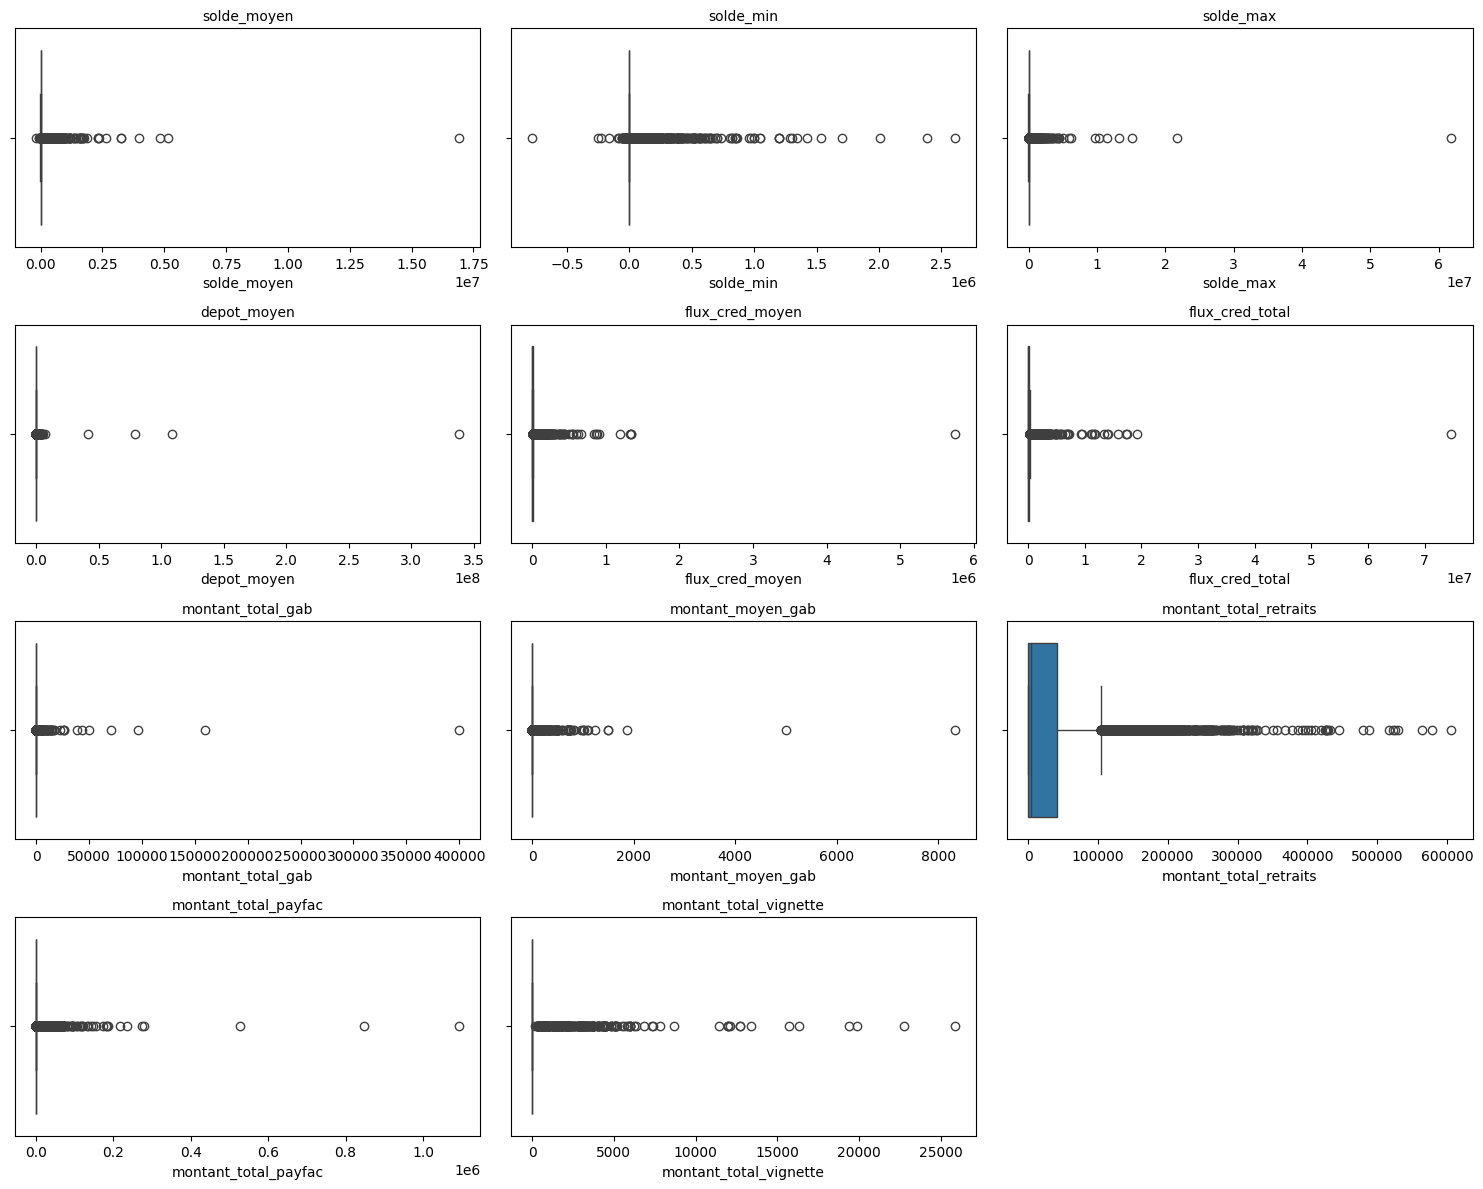

  Lignes avant/après (valeurs impossibles, train) : 3172296 -> 3172296

Détection des colonnes zero-inflated (train) :


  montant_total_gab            -> zero-inflated (93% de zéros)


  montant_moyen_gab            -> zero-inflated (93% de zéros)


  montant_total_payfac         -> zero-inflated (80% de zéros)


  montant_total_vignette       -> zero-inflated (95% de zéros)


...

montant_total_gab            min=         0.0 max=       1733.75 mean=32.0 médiane=0.0 p1=0.0 p99=1733.8 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=208835


montant_moyen_gab            min=         0.0 max=50.78846153846154 mean=0.9 médiane=0.0 p1=0.0 p99=50.8 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=208835


montant_total_retraits       min=         0.0 max=      101750.0 mean=23963.1 médiane=3600.0 p1=0.0 p99=101750.0 bornes_IQR=[-61050.0,101750.0] négatifs=0 hors_bornes=0


montant_total_payfac         min=         0.0 max=      22781.33 mean=1289.9 médiane=0.0 p1=0.0 p99=22781.3 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=644948


montant_total_vignette       min=         0.0 max=        3075.0 mean=72.3 médiane=0.0 p1=0.0 p99=3075.0 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=159615


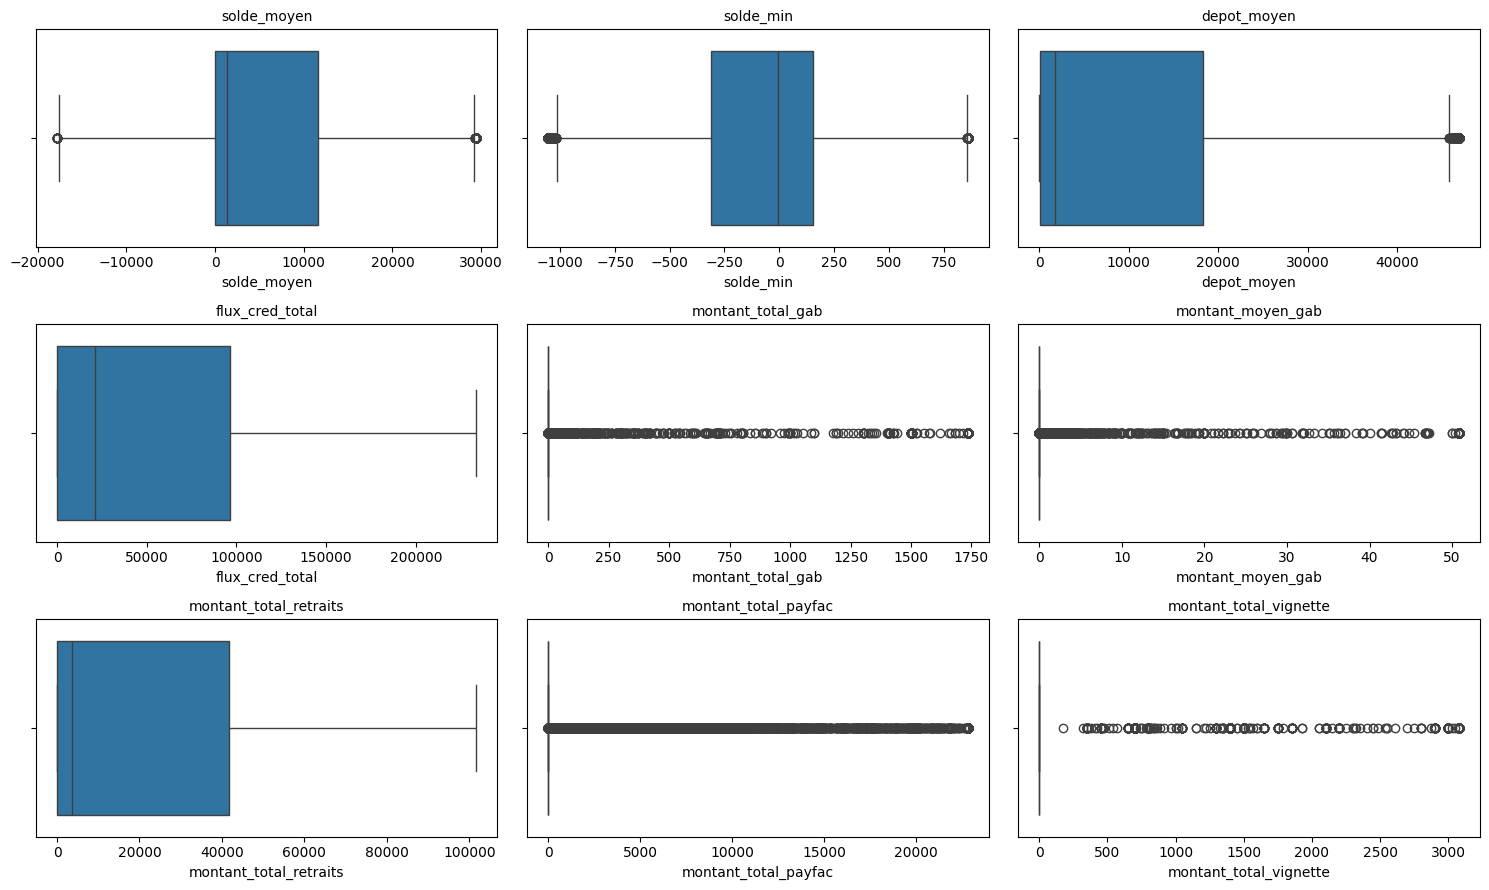


Écriture : s3a://processed-data/dataset_eligibilite_final/


OK : dataset_train_produits -> 3172296 lignes, 42 colonnes.


In [19]:
df_train_final = traiter_dataset(PATH_TRAIN_IN, PATH_TRAIN_OUT, is_train=True, label="dataset_train_produits")


In [ ]:
diagnostic_correlations(df_train_final)

In [ ]:
df_train_final.groupBy("solde_moyen_etait_extreme").count().show()

+-------------------------+-----+
|solde_moyen_etait_extreme|count|
+-------------------------+-----+
|                        1|  554|
|                        0| 3451|
+-------------------------+-----+



In [ ]:
import pandas as pd

path = "/home/yahya/Desktop/bigdata-cluster/analytics/new_test/part-00000_final.parquet/"
df = pd.read_parquet(path)

# Just evaluate the expression at the end of the cell
df.head() 

# Or explicitly use display:
display(df.head())
df.to_csv("final.csv", index=False)

,CODE_VILLE,BPR,GENDER,MARITAL_STATUS,NOMBRE_ENFANT,CUSTOMER_RATING,TAILLE_ENTREPRI,age_client,label_code,label_nom,...,nb_mois_observes_solde_etait_extreme,solde_moyen_etait_extreme,solde_min_etait_extreme,solde_max_etait_extreme,depot_moyen_etait_extreme,flux_cred_moyen_etait_extreme,flux_cred_total_etait_extreme,montant_total_retraits_etait_extreme,solde_volatilite_indefinie,solde_volatilite_relative_imp
0,101,45,M,9,0,SVC,PARTICULIER,28,09,MaRetraite,...,0,0,0,0,0,0,0,0,1,3.550722
1,780,78,M,1,0,SVC,PARTICULIER,31,09,MaRetraite,...,1,0,1,0,0,0,0,0,1,3.550722
2,780,78,M,1,0,SVC,PARTICULIER,32,09,MaRetraite,...,0,0,0,0,0,0,0,0,1,3.550722
3,780,78,M,1,0,SVC,PARTICULIER,53,09,MaRetraite,...,0,0,0,0,0,0,0,0,1,3.550722
4,780,78,M,1,0,SVC,PARTICULIER,35,09,MaRetraite,...,1,0,0,0,0,0,0,0,0,6.973914


In [ ]:
# À décommenter une fois LOCAL_MODE = False et dataset_a_scorer disponible sur MinIO :
# df_scorer_final = traiter_dataset(PATH_SCORER_IN, PATH_SCORER_OUT, is_train=False, label="dataset_a_scorer")
